In [9]:
def plot_sentiment_drift(
    updated_time_series,
    freq="D",
    value_col=None,
    title="Sentiment Drift Over Time",
    subtitle=None,
    figsize=(17, 8.5),
    save_path=None
):
    """
    Plot a professional sentiment drift visualization with volume bubbles,
    average sentiment, and a smoothed trend line.

    Sentiment scale:
        0 = Negative
        1 = Neutral
        2 = Positive
    """

    valid_freqs = {"D", "W", "M"}
    freq = str(freq).upper()

    if freq not in valid_freqs:
        raise ValueError(
            "Invalid freq. Use one of: 'D' for daily, 'W' for weekly, or 'M' for monthly."
        )

    if not isinstance(updated_time_series, pd.DataFrame):
        raise ValueError("updated_time_series must be a pandas DataFrame.")

    if updated_time_series.empty:
        raise ValueError("updated_time_series is empty.")

    if value_col is None:
        value_col = updated_time_series.columns[0]
    elif value_col not in updated_time_series.columns:
        raise ValueError(f"value_col '{value_col}' does not exist in the DataFrame.")

    df = updated_time_series[[value_col]].copy()
    df.columns = ["sentiment"]

    df.index = pd.to_datetime(df.index, errors="coerce")
    df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")

    df = df.dropna(subset=["sentiment"])
    df = df[df.index.notna()]

    if df.empty:
        raise ValueError("No valid sentiment scores remain after cleaning.")

    df = df.sort_index()
    df["sentiment"] = df["sentiment"].clip(0, 2)

    # Classify sentiment into lanes.
    df["sentiment_class"] = pd.cut(
        df["sentiment"],
        bins=[-0.001, 0.5, 1.5, 2.001],
        labels=["Negative", "Neutral", "Positive"],
        include_lowest=True
    )

    if df["sentiment_class"].isna().all():
        raise ValueError("No valid sentiment classes could be created.")

    grouped = df.resample(freq)

    avg_sentiment = grouped["sentiment"].mean()
    counts = (
        df.groupby([pd.Grouper(freq=freq), "sentiment_class"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Negative", "Neutral", "Positive"], fill_value=0)
    )

    plot_index = avg_sentiment.dropna().index

    if len(plot_index) == 0:
        raise ValueError("No valid time periods remain after aggregation.")

    counts = counts.loc[counts.index.isin(plot_index)]
    avg_sentiment = avg_sentiment.loc[plot_index]

    rolling_window = {"D": 7, "W": 4, "M": 3}[freq]
    smooth_sentiment = avg_sentiment.rolling(
        window=rolling_window,
        min_periods=1
    ).mean()

    lane_y = {
        "Negative": 0,
        "Neutral": 1,
        "Positive": 2
    }

    lane_colors = {
        "Negative": "#D95F5F",
        "Neutral": "#8E9AAF",
        "Positive": "#4C9F70"
    }

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Reserve space for title/subtitle, note, and outside legend.
    fig.subplots_adjust(left=0.08, right=0.78, top=0.82, bottom=0.20)

    max_count = counts.to_numpy().max()
    if max_count <= 0:
        raise ValueError("No observations available to plot after aggregation.")

    min_bubble = 60
    max_bubble = 950

    for sentiment_class in ["Negative", "Neutral", "Positive"]:
        class_counts = counts[sentiment_class]
        nonzero = class_counts[class_counts > 0]

        if nonzero.empty:
            continue

        bubble_sizes = (
            min_bubble
            + (np.sqrt(nonzero) / np.sqrt(max_count)) * (max_bubble - min_bubble)
        )

        ax.scatter(
            nonzero.index,
            np.full(len(nonzero), lane_y[sentiment_class]),
            s=bubble_sizes,
            color=lane_colors[sentiment_class],
            alpha=0.42,
            edgecolor="white",
            linewidth=1.3,
            label=sentiment_class,
            zorder=3
        )

    ax.plot(
        avg_sentiment.index,
        avg_sentiment.values,
        color="#1F2937",
        linewidth=2.6,
        marker="o",
        markersize=4.5,
        markerfacecolor="white",
        markeredgewidth=1.4,
        label="Average sentiment",
        zorder=4
    )

    ax.plot(
        smooth_sentiment.index,
        smooth_sentiment.values,
        color="#111827",
        linewidth=2.4,
        linestyle="--",
        alpha=0.78,
        label=f"Smoothed trend ({rolling_window}-period rolling mean)",
        zorder=5
    )

    ax.set_ylim(-0.35, 2.35)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["Negative", "Neutral", "Positive"], fontsize=12)
    ax.set_ylabel("Sentiment Lane", fontsize=12, labelpad=14)
    ax.set_xlabel("Date", fontsize=12, labelpad=12)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=10))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

    ax.grid(axis="y", color="#E5E7EB", linewidth=1.0)
    ax.grid(axis="x", color="#F3F4F6", linewidth=0.8, alpha=0.7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D1D5DB")
    ax.spines["bottom"].set_color("#D1D5DB")

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=12)

    fig.text(
        0.08,
        0.92,
        title,
        ha="left",
        va="top",
        fontsize=22,
        fontweight="bold",
        color="#111827"
    )

    if subtitle:
        fig.text(
            0.08,
            0.875,
            subtitle,
            ha="left",
            va="top",
            fontsize=13.5,
            color="#4B5563"
        )

    note = (
        "Bubble size represents observation volume per sentiment class and period. "
        "The solid line shows average sentiment; the dashed line shows the rolling trend. "
        "Sentiment scores are clamped to the [0, 2] range for plotting."
    )

    fig.text(
        0.08,
        0.065,
        note,
        ha="left",
        va="bottom",
        fontsize=10.5,
        color="#6B7280"
    )

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=lane_colors["Negative"],
            markeredgecolor="white",
            markersize=11,
            alpha=0.65,
            label="Negative volume"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=lane_colors["Neutral"],
            markeredgecolor="white",
            markersize=11,
            alpha=0.65,
            label="Neutral volume"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=lane_colors["Positive"],
            markeredgecolor="white",
            markersize=11,
            alpha=0.65,
            label="Positive volume"
        ),
        Line2D(
            [0], [0],
            color="#1F2937",
            linewidth=2.6,
            marker="o",
            markerfacecolor="white",
            label="Average sentiment"
        ),
        Line2D(
            [0], [0],
            color="#111827",
            linewidth=2.4,
            linestyle="--",
            alpha=0.78,
            label="Smoothed trend"
        )
    ]

    ax.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=11,
        title="Legend",
        title_fontsize=12
    )

    if save_path:
        fig.savefig(
            save_path,
            dpi=220,
            bbox_inches="tight",
            facecolor="white"
        )

    return fig, ax


In [10]:
def sentiment_drift_from_csv(
    csv_path,
    text_col="post_text",
    date_col="created_at_raw",
    bot_pipeline_path="../models/bot_identification/bot_identification.joblib",
    sentiment_model_path="../models/roberta_model",
    freq="D",
    title="Sentiment Drift Over Time",
    subtitle=None,
    figsize=(16, 8),
    save_path=None,
    remove_bots=True,
    bot_label=1,
    max_length=128,
    batch_size=32
):
    """
    Full CSV → optional bot filtering → sentiment scoring → sentiment drift graph.

    Assumptions:
        - Every CSV has the same feature names.
        - text_col contains the text to classify.
        - date_col contains the timestamp/date.
        - The sentiment model output has:
              item["score"] = actual sentiment value
          where sentiment is already on the scale used by plot_sentiment_drift:
              0 = Negative
              1 = Neutral
              2 = Positive

    Returns:
        A dictionary containing:
            - fig
            - ax
            - cleaned_df
            - time_series
            - raw_sentiment_outputs
    """

    import pandas as pd
    import joblib
    import torch
    from transformers import pipeline

    from pathlib import Path
    import re
    
    csv_stem = Path(csv_path).stem
    csv_title = csv_stem.replace("_", " ").replace("-", " ").title()
    
    title = f"Sentiment Drift for {csv_title}"
    
    safe_csv_name = re.sub(r"[^A-Za-z0-9_-]+", "_", csv_stem).strip("_")
    save_path = f"sentiment_drift_for_{safe_csv_name}.png"

    # -----------------------------
    # 1. Load CSV
    # -----------------------------
    df = pd.read_csv(csv_path)

    required_cols = [text_col, date_col]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(
            f"CSV is missing required columns: {missing_cols}. "
            f"Available columns: {list(df.columns)}"
        )

    df = df[[text_col, date_col]].copy()
    df = df.dropna(subset=[text_col, date_col])

    if df.empty:
        raise ValueError("No usable rows remain after dropping missing text/date values.")

    df[text_col] = df[text_col].astype(str)

    # -----------------------------
    # 2. Remove bot posts
    # -----------------------------
    if remove_bots:
        bot_pipeline = joblib.load(bot_pipeline_path)

        bot_predictions = bot_pipeline.predict(df[text_col].to_numpy())

        df = df.loc[bot_predictions != bot_label].copy()

        if df.empty:
            raise ValueError("All rows were removed by the bot filter.")

    # -----------------------------
    # 3. Clean dates
    # -----------------------------
    df["date"] = pd.to_datetime(
        df[date_col].astype(str).str[:10],
        errors="coerce"
    )

    df = df.dropna(subset=["date"])

    if df.empty:
        raise ValueError("No valid dates remain after date parsing.")

    # -----------------------------
    # 4. Load sentiment model
    # -----------------------------
    device = 0 if torch.cuda.is_available() else -1

    sentiment_classifier = pipeline(
        "sentiment-analysis",
        model=sentiment_model_path,
        device=device
    )

    # -----------------------------
    # 5. Run sentiment prediction in batches
    # -----------------------------
    texts = df[text_col].tolist()
    raw_sentiment_outputs = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]

        batch_outputs = sentiment_classifier(
            batch,
            truncation=True,
            padding=True,
            max_length=max_length
        )

        raw_sentiment_outputs.extend(batch_outputs)

    # -----------------------------
    # 6. Use item["score"] as actual sentiment value
    # -----------------------------
    df["sentiment"] = [
        float(item["score"])
        for item in raw_sentiment_outputs
    ]

    # Optional safety clamp for plotting
    df["sentiment"] = df["sentiment"].clip(0, 2)

    # -----------------------------
    # 7. Build time series
    # -----------------------------
    time_series = (
        df[["date", "sentiment"]]
        .set_index("date")
        .sort_index()
    )

    # -----------------------------
    # 8. Plot sentiment drift
    # -----------------------------
    fig, ax = plot_sentiment_drift(
        updated_time_series=time_series,
        freq=freq,
        value_col="sentiment",
        title=title,
        subtitle=subtitle,
        figsize=figsize,
        save_path=save_path
    )

    return {
        "fig": fig,
        "ax": ax,
        "cleaned_df": df,
        "time_series": time_series,
        "raw_sentiment_outputs": raw_sentiment_outputs
    }

c:\Users\jarre\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.4.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\jarre\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.4.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\jarre\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FeatureUnion from version 1.4.2 when using version 1.8.0. This might lead to breakin

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

NameError: name 'mdates' is not defined

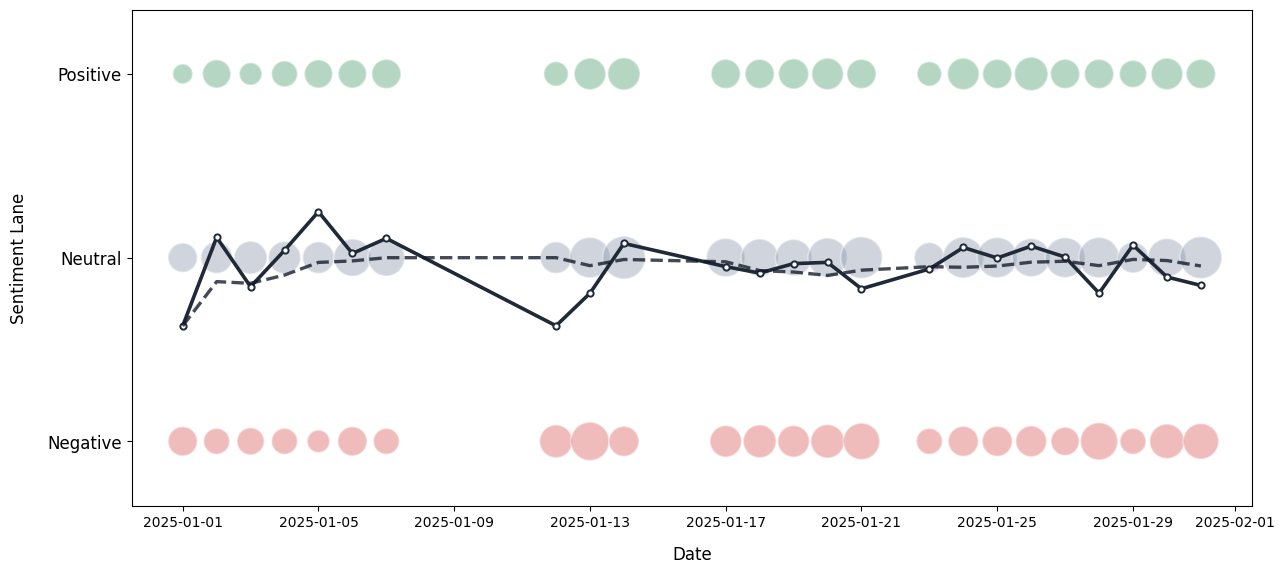

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

output = sentiment_drift_from_csv(
    csv_path="../data/climate_change/climate_change_jan_2025.csv",
    freq="D",
    title="Sentiment Drift Over Time for Climate Change",
    save_path="../sentiment_drift_graphs/climate_change_sentiment_drift.png"
)